In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
dose_response = pd.read_csv("../data/raw/GDSC2_fitted_dose_response.csv")
dose_response.head()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [9]:
dose_response.shape
dose_response.info()

<class 'pandas.DataFrame'>
RangeIndex: 242036 entries, 0 to 242035
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   DATASET          242036 non-null  str    
 1   NLME_RESULT_ID   242036 non-null  int64  
 2   NLME_CURVE_ID    242036 non-null  int64  
 3   CELL_LINE_NAME   242036 non-null  str    
 4   SANGER_MODEL_ID  242036 non-null  str    
 5   CANCER_TYPE      242036 non-null  str    
 6   DRUG_ID          242036 non-null  int64  
 7   DRUG_NAME        242036 non-null  str    
 8   PUTATIVE_TARGET  214164 non-null  str    
 9   PATHWAY_NAME     242036 non-null  str    
 10  MIN_CONC         242036 non-null  float64
 11  MAX_CONC         242036 non-null  float64
 12  LN_IC50          242036 non-null  float64
 13  AUC              242036 non-null  float64
 14  RMSE             242036 non-null  float64
 15  Z_SCORE          242036 non-null  float64
dtypes: float64(6), int64(3), str(7)
memory usage: 29.

In [10]:
dose_response.isna().sum()

DATASET                0
NLME_RESULT_ID         0
NLME_CURVE_ID          0
CELL_LINE_NAME         0
SANGER_MODEL_ID        0
CANCER_TYPE            0
DRUG_ID                0
DRUG_NAME              0
PUTATIVE_TARGET    27872
PATHWAY_NAME           0
MIN_CONC               0
MAX_CONC               0
LN_IC50                0
AUC                    0
RMSE                   0
Z_SCORE                0
dtype: int64

In [70]:
dose_response[dose_response['PUTATIVE_TARGET'].isna()]['DRUG_NAME'].unique()

<StringArray>
[                'GSK2801',             'Zoledronate',
                'Acetalax',              'Teniposide',
              'Nelarabine',                  '123829',
                  '765771',                  '123138',
 'Podophyllotoxin bromide',                   '50869',
         'Dihydrorotenone',                  '720427',
                  '667880',     'Gallibiscoquinazole',
       'L-Oxonoreleagnine',                  '729189',
                  '741909',                  '743380',
              'Elephantin',                  '150412',
               'Sinularin',                  '615590',
                  '630600',                  '776928',
        'Schweinfurthin A',                     'BEN',
            'BPD-00008900',            'N25720-51-A1',
             'N27922-53-1',             'N30652-18-1',
             'N29087-69-1',             'HKMTI-1-005',
       'Mycophenolic acid',               'Remodelin',
                   'VTP-A',                   'VTP-

<Axes: xlabel='AUC', ylabel='Count'>

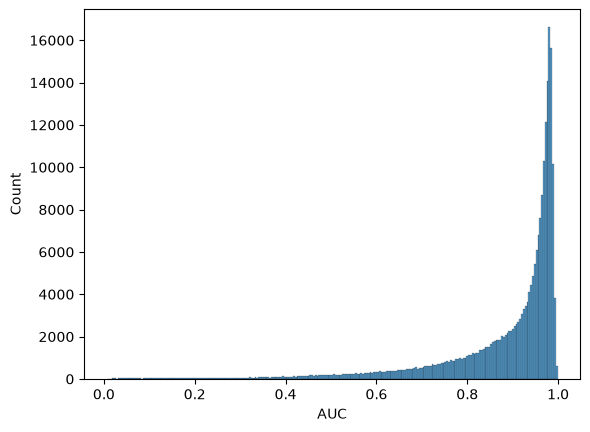

In [12]:
sns.histplot(dose_response['AUC'])

In [76]:
dose_response.groupby('DRUG_NAME')['AUC'].mean()

DRUG_NAME
123138                   0.975513
123829                   0.917556
150412                   0.953330
5-Fluorouracil           0.901972
5-azacytidine            0.838578
                           ...   
ZM447439                 0.849665
Zoledronate              0.979930
alpha-lipoic acid        0.973668
ascorbate (vitamin C)    0.964159
glutathione              0.970576
Name: AUC, Length: 286, dtype: float64

In [15]:
dose_response['DRUSSG_NAME'].nunique()

286

In [72]:
drug_counts = dose_response.groupby('DRUG_NAME')['CELL_LINE_NAME'].count()
drugs_over_900 = drug_counts[drug_counts > 900]
drugs_over_900

DRUG_NAME
5-Fluorouracil    968
ABT737            957
AGI-5198          958
AGK2              933
AMG-319           950
                 ... 
WEHI-539          962
WIKI4             957
Wee1 Inhibitor    957
YK-4-279          958
ZM447439          944
Name: CELL_LINE_NAME, Length: 131, dtype: int64

In [52]:
rnatpm = pd.read_csv("../data/raw/rnaseq_merged_rsem_tpm.csv")
rnatpm.head()

/var/folders/9q/gqc16n3531j80hck107z1jf00000gn/T/ipykernel_32831/1841106054.py:1: DtypeWarning: Columns (0: SIDM00001, 1: SIDM00002, 2: SIDM00003, 3: SIDM00005, 4: SIDM00006, 5: SIDM00007, 6: SIDM00008, 7: SIDM00009, 8: SIDM00011, 9: SIDM00014, 10: SIDM00015, 11: SIDM00016, 12: SIDM00017, 13: SIDM00018, 14: SIDM00023, 15: SIDM00025, 16: SIDM00026, 17: SIDM00027, 18: SIDM00028, 19: SIDM00029, 20: SIDM00032, 21: SIDM00035, 22: SIDM00036, 23: SIDM00037, 24: SIDM00040, 25: SIDM00041, 26: SIDM00042, 27: SIDM00043, 28: SIDM00044, 29: SIDM00045, 30: SIDM00046, 31: SIDM00047, 32: SIDM00048, 33: SIDM00049, 34: SIDM00050, 35: SIDM00051, 36: SIDM00052, 37: SIDM00053, 38: SIDM00056, 39: SIDM00057, 40: SIDM00058, 41: SIDM00062, 42: SIDM00063, 43: SIDM00064, 44: SIDM00065, 45: SIDM00068, 46: SIDM00070, 47: SIDM00071, 48: SIDM00072, 49: SIDM00073, 50: SIDM00074, 51: SIDM00077, 52: SIDM00078, 53: SIDM00079, 54: SIDM00080, 55: SIDM00081, 56: SIDM00082, 57: SIDM00083, 58: SIDM00084, 59: SIDM00085, 60: S

,model_id,Unnamed: 1,Unnamed: 2,SIDM00001,SIDM00002,SIDM00003,SIDM00005,SIDM00006,SIDM00007,SIDM00008,...,SIDM02262,SIDM02263,SIDM02264,SIDM02265,SIDM02266,SIDM02267,SIDM02268,SIDM02269,SIDM02270,SIDM02271
0,model_name,NaN,NaN,MEC-1,NBsusSR,M14,MDA-MB-134-VI,MCC26,MCC13,MCAS,...,WTSI-COLO_427,WTSI-COLO_425,WTSI-COLO_061,WTSI-COLIVM_100,WTSI-COLIVM_093,WTSI-COLIVM_092,WTSI-COLO_452,WTSI-PANC_131,WTSI-COLIVM_068,WTSI-GAST_200
1,data_source,NaN,NaN,Broad,Sanger,Sanger,Broad,Sanger,Sanger,Broad,...,Sanger,Sanger,Sanger,Sanger,Sanger,Sanger,Sanger,Sanger,Sanger,Sanger
2,gene_symbol,ensembl_gene_id,gene_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1BG,ENSG00000121410,SIDG00001,3.853,4.5059,3.9736,5.7038,3.9069,6.1198,0.0566,...,0.1635,0.848,0.2869,0.189,0.5361,3.5583,2.9635,0,0.0976,0
4,A1BG-AS1,ENSG00000268895,SIDG00002,1.8156,2.3868,3.1408,3.3334,2.5801,3.5336,0.0976,...,0,0,0.189,0.0976,0.2141,0.4957,0.3334,0.8953,0.2869,0


In [53]:
tpm_header = pd.read_csv("../data/raw/rnaseq_merged_rsem_tpm.csv", header=None, nrows=1)
tpm_cell_lines = set(tpm_header.iloc[0,3:]) # skip first 3 label columns 

In [46]:
dose_response['HAS_EXPRESSION'] = dose_response['SANGER_MODEL_ID'].isin(tpm_cell_lines)

In [47]:
dose_response.head()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,HAS_EXPRESSION
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123,True
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100,True
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569,True
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647,True
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232,True


In [87]:
dose_response[dose_response['DRUG_ID'] == 1053]

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,HAS_EXPRESSION
36441,GDSC2,343,15946336,PFSK-1,SIDM01132,Other Solid Cancers,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.010005,10.0,1.878411,0.847013,0.165206,-0.569114,True
36442,GDSC2,343,15946586,A673,SIDM00848,Ewing's Sarcoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.010005,10.0,3.296323,0.941007,0.111567,0.385000,True
36443,GDSC2,343,15946869,ES5,SIDM00263,Ewing's Sarcoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.010005,10.0,1.076282,0.773510,0.118491,-1.108866,True
36444,GDSC2,343,15947125,ES7,SIDM00269,Ewing's Sarcoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.010005,10.0,1.535589,0.820656,0.136426,-0.799799,True
36445,GDSC2,343,15947407,EW-11,SIDM00203,Ewing's Sarcoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.010005,10.0,0.975579,0.745613,0.129673,-1.176629,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37404,GDSC2,343,16188461,SNU-407,SIDM00214,Colorectal Carcinoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.009766,10.0,2.471248,0.867337,0.086082,-0.170193,True
37405,GDSC2,343,16188734,SNU-61,SIDM00194,Colorectal Carcinoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.010005,10.0,4.405050,0.957636,0.081518,1.131063,True
37406,GDSC2,343,16188993,SNU-81,SIDM00193,Colorectal Carcinoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.009766,10.0,2.848686,0.927789,0.133609,0.083785,True
37407,GDSC2,343,16189250,SNU-C5,SIDM00498,Colorectal Carcinoma,1053,MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,0.009766,10.0,2.303834,0.844495,0.083246,-0.282846,True


In [81]:
dose_response.groupby('DRUG_ID')['SANGER_MODEL_ID'].count()

DRUG_ID
1003    968
1004    741
1005    760
1006    743
1007    967
       ... 
2362    731
2438    732
2439    732
2498    735
2499    735
Name: SANGER_MODEL_ID, Length: 295, dtype: int64

In [74]:
dose_response['SANGER_MODEL_ID'].nunique()

969

In [63]:
id_per_name = dose_response.groupby('DRUG_NAME')['DRUG_ID'].nunique()
id_per_name[id_per_name > 1]

DRUG_NAME
Acetalax        2
Dactinomycin    2
Docetaxel       2
Fulvestrant     2
GSK343          2
Oxaliplatin     2
Selumetinib     2
Ulixertinib     2
Uprosertib      2
Name: DRUG_ID, dtype: int64

In [67]:
dose_response['HAS_EXPRESSION'].value_counts()

HAS_EXPRESSION
True     235800
False      6236
Name: count, dtype: int64

In [96]:
real_counts = dose_response[dose_response['HAS_EXPRESSION']].groupby('DRUG_ID')['SANGER_MODEL_ID'].count().sort_values(ascending=False)
real_counts = real_counts[real_counts >= 400]
real_counts

DRUG_ID
1862    944
1053    943
1073    943
1060    943
1034    943
       ... 
1428    695
1720    694
1712    694
1819    651
1248    578
Name: SANGER_MODEL_ID, Length: 279, dtype: int64

In [98]:
auc_stats = dose_response[
    dose_response['HAS_EXPRESSION'] & dose_response['DRUG_ID'].isin(real_counts.index)
].groupby('DRUG_ID')['AUC'].agg(['std', 'mean', 'count'])

auc_stats.sort_values('std', ascending=False)

,std,mean,count
DRUG_ID,,,
1819,0.299588,0.492790,651
1494,0.267164,0.758818,933
1190,0.241209,0.645131,935
1248,0.228221,0.624968,578
1709,0.203147,0.502632,697
...,...,...,...
1783,0.011097,0.978760,698
1776,0.010669,0.980366,698
1620,0.010599,0.979677,871


In [120]:
dose_response[dose_response['DRUG_ID'].isin([1819, 1494])][['DRUG_ID', 'DRUG_NAME']].drop_duplicates()


,DRUG_ID,DRUG_NAME
83645,1494,SN-38
153655,1819,Docetaxel


<Axes: xlabel='AUC', ylabel='Count'>

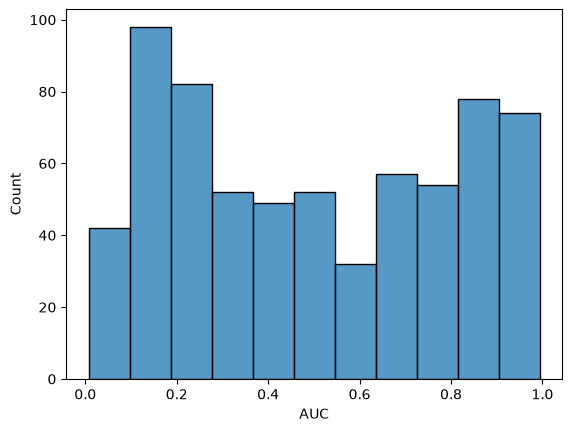

In [148]:
sns.histplot(dose_response[dose_response['DRUG_ID'] == 1819]['AUC'])

<Axes: ylabel='Count'>

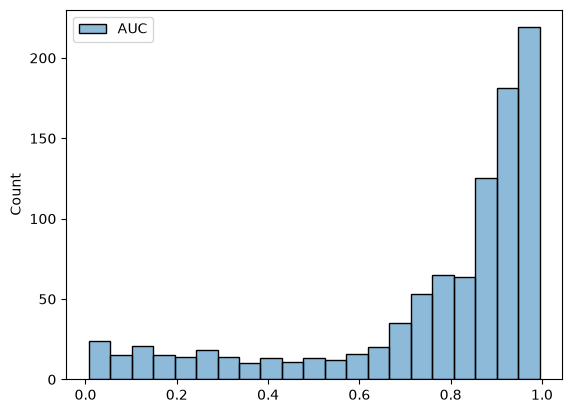

In [147]:
sns.histplot([dose_response[dose_response['DRUG_ID']  == 1494]['AUC']])

In [133]:
dose_response[dose_response['DRUG_ID'] == 1819]

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,HAS_EXPRESSION
153655,GDSC2,343,15946460,PFSK-1,SIDM01132,Other Solid Cancers,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-4.228011,0.267990,0.193469,-0.716106,True
153656,GDSC2,343,15946725,A673,SIDM00848,Ewing's Sarcoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-5.961688,0.105028,0.100721,-1.287601,True
153657,GDSC2,343,15947012,ES5,SIDM00263,Ewing's Sarcoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-4.880559,0.195845,0.249086,-0.931214,True
153658,GDSC2,343,15947264,ES7,SIDM00269,Ewing's Sarcoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-6.322894,0.082177,0.147412,-1.406670,True
153659,GDSC2,343,15947546,EW-11,SIDM00203,Ewing's Sarcoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-4.026132,0.302620,0.258046,-0.649558,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154320,GDSC2,343,16188599,SNU-407,SIDM00214,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,0.480647,0.806790,0.194186,0.836070,True
154321,GDSC2,343,16188869,SNU-61,SIDM00194,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,0.309659,0.794573,0.247667,0.779705,True
154322,GDSC2,343,16189137,SNU-81,SIDM00193,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-1.969038,0.551563,0.218863,0.028548,True
154323,GDSC2,343,16189388,SNU-C5,SIDM00498,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0,-3.551922,0.364316,0.163964,-0.493238,True


In [134]:
dose_response[dose_response['DRUG_ID'] == 1819].isna().sum()

DATASET            0
NLME_RESULT_ID     0
NLME_CURVE_ID      0
CELL_LINE_NAME     0
SANGER_MODEL_ID    0
CANCER_TYPE        0
DRUG_ID            0
DRUG_NAME          0
PUTATIVE_TARGET    0
PATHWAY_NAME       0
MIN_CONC           0
MAX_CONC           0
LN_IC50            0
AUC                0
RMSE               0
Z_SCORE            0
HAS_EXPRESSION     0
dtype: int64

In [135]:
dose_response[dose_response['DRUG_ID'] == 1819]['DRUG_NAME'].nunique()

1

In [142]:
dose_response[dose_response['DRUG_NAME'] == 'Docetaxel']

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,HAS_EXPRESSION
3212,GDSC2,343,15946314,PFSK-1,SIDM01132,Other Solid Cancers,1007,Docetaxel,Microtubule stabiliser,Mitosis,0.000013,0.0125,-5.534417,0.778336,0.105524,-0.750908,True
3213,GDSC2,343,15946552,A673,SIDM00848,Ewing's Sarcoma,1007,Docetaxel,Microtubule stabiliser,Mitosis,0.000013,0.0125,-6.170717,0.710671,0.096913,-1.156890,True
3214,GDSC2,343,15946831,ES5,SIDM00263,Ewing's Sarcoma,1007,Docetaxel,Microtubule stabiliser,Mitosis,0.000013,0.0125,-5.984052,0.732039,0.071115,-1.037791,True
3215,GDSC2,343,15947091,ES7,SIDM00269,Ewing's Sarcoma,1007,Docetaxel,Microtubule stabiliser,Mitosis,0.000013,0.0125,-6.284694,0.697466,0.098866,-1.229612,True
3216,GDSC2,343,15947373,EW-11,SIDM00203,Ewing's Sarcoma,1007,Docetaxel,Microtubule stabiliser,Mitosis,0.000013,0.0125,-4.686362,0.838586,0.073598,-0.209817,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154320,GDSC2,343,16188599,SNU-407,SIDM00214,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0000,0.480647,0.806790,0.194186,0.836070,True
154321,GDSC2,343,16188869,SNU-61,SIDM00194,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0000,0.309659,0.794573,0.247667,0.779705,True
154322,GDSC2,343,16189137,SNU-81,SIDM00193,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0000,-1.969038,0.551563,0.218863,0.028548,True
154323,GDSC2,343,16189388,SNU-C5,SIDM00498,Colorectal Carcinoma,1819,Docetaxel,Microtubule stabiliser,Mitosis,0.003002,3.0000,-3.551922,0.364316,0.163964,-0.493238,True
